In [ ]:
pip install konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 488.6/488.6 kB 12.7 MB/s eta 0:00:00


## 1. 원-핫 인코딩(One-hot encoding)이란?

In [ ]:
from konlpy.tag import Okt
okt = Okt()
token = okt.morphs("나는 자연어 처리를 배운다")
print(token)

['나', '는', '자연어', '처리', '를', '배운다']


In [ ]:
word2index = {}
for voca in token:
     if voca not in word2index.keys():
       word2index[voca] = len(word2index)
print(word2index)

{'나': 0, '는': 1, '자연어': 2, '처리': 3, '를': 4, '배운다': 5}


In [ ]:
def one_hot_encoding(word, word2index):
    one_hot_vector = [0]*(len(word2index))
    index = word2index[word]
    one_hot_vector[index] = 1
    return one_hot_vector

In [ ]:
one_hot_encoding("자연어",word2index)

[0, 0, 1, 0, 0, 0]

In [ ]:
import torch

In [ ]:
# 원-핫 벡터 생성
dog = torch.FloatTensor([1, 0, 0, 0, 0])
cat = torch.FloatTensor([0, 1, 0, 0, 0])
computer = torch.FloatTensor([0, 0, 1, 0, 0])
netbook = torch.FloatTensor([0, 0, 0, 1, 0])
book = torch.FloatTensor([0, 0, 0, 0, 1])

In [ ]:
print(torch.cosine_similarity(dog, cat, dim=0))
print(torch.cosine_similarity(cat, computer, dim=0))
print(torch.cosine_similarity(computer, netbook, dim=0))
print(torch.cosine_similarity(netbook, book, dim=0))


tensor(0.)
tensor(0.)
tensor(0.)
tensor(0.)


In [ ]:
import gensim
gensim.__version__

'4.3.3'

In [ ]:
pip install konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 488.6/488.6 kB 25.8 MB/s eta 0:00:00


# 1. 영어 Word2Vec

In [ ]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
import urllib.request
import zipfile
from lxml import etree
import re
from nltk.tokenize import word_tokenize, sent_tokenize

In [ ]:
# 데이터 다운로드
urllib.request.urlretrieve("https://raw.githubusercontent.com/ukairia777/tensorflow-nlp-tutorial/main/09.%20Word%20Embedding/dataset/ted_en-20160408.xml", filename="ted_en-20160408.xml")

('ted_en-20160408.xml', <http.client.HTTPMessage at 0x79ccf213e560>)

In [ ]:
targetXML = open('ted_en-20160408.xml', 'r', encoding='UTF8')
target_text = etree.parse(targetXML)

# xml 파일로부터 <content>와 </content> 사이의 내용만 가져온다.
parse_text = '\n'.join(target_text.xpath('//content/text()'))

# 정규 표현식의 sub 모듈을 통해 content 중간에 등장하는 (Audio), (Laughter) 등의 배경음 부분을 제거.
# 해당 코드는 괄호로 구성된 내용을 제거.
content_text = re.sub(r'\([^)]*\)', '', parse_text)

# 입력 코퍼스에 대해서 NLTK를 이용하여 문장 토큰화를 수행.
sent_text = sent_tokenize(content_text)

# 각 문장에 대해서 구두점을 제거하고, 대문자를 소문자로 변환.
normalized_text = []
for string in sent_text:
     tokens = re.sub(r"[^a-z0-9]+", " ", string.lower())
     normalized_text.append(tokens)

# 각 문장에 대해서 NLTK를 이용하여 단어 토큰화를 수행.
result = [word_tokenize(sentence) for sentence in normalized_text]

In [ ]:
print('총 샘플의 개수 : {}'.format(len(result)))

총 샘플의 개수 : 273424


In [ ]:
# 샘플 3개만 출력
for line in result[:3]:
    print(line)

['here', 'are', 'two', 'reasons', 'companies', 'fail', 'they', 'only', 'do', 'more', 'of', 'the', 'same', 'or', 'they', 'only', 'do', 'what', 's', 'new']
['to', 'me', 'the', 'real', 'real', 'solution', 'to', 'quality', 'growth', 'is', 'figuring', 'out', 'the', 'balance', 'between', 'two', 'activities', 'exploration', 'and', 'exploitation']
['both', 'are', 'necessary', 'but', 'it', 'can', 'be', 'too', 'much', 'of', 'a', 'good', 'thing']


In [ ]:
from gensim.models import Word2Vec
from gensim.models import KeyedVectors

In [ ]:
model = Word2Vec(sentences=result, vector_size=100, window=5, min_count=5, workers=4, sg=0)

여기서 Word2Vec의 인자는 다음과 같습니다.  

* size = 워드 벡터의 특징 값. 즉, 임베딩 된 벡터의 차원.
* window = 컨텍스트 윈도우 크기
* min_count = 단어 최소 빈도 수 제한 (빈도가 적은 단어들은 학습하지 않는다.)
* workers = 학습을 위한 프로세스 수
* sg = 0은 CBOW, 1은 Skip-gram.

In [ ]:
model_result = model.wv.most_similar("man")
print(model_result)

[('woman', 0.8479083776473999), ('guy', 0.813675045967102), ('boy', 0.7598490715026855), ('girl', 0.7490219473838806), ('lady', 0.7394067645072937), ('gentleman', 0.7307337522506714), ('soldier', 0.701229453086853), ('poet', 0.6863505840301514), ('kid', 0.6715146899223328), ('writer', 0.6641169190406799)]


In [ ]:
model.wv.save_word2vec_format('eng_w2v') # 모델 저장
loaded_model = KeyedVectors.load_word2vec_format("eng_w2v") # 모델 로드

In [ ]:
model_result = loaded_model.most_similar("man")
print(model_result)

[('woman', 0.8479083776473999), ('guy', 0.813675045967102), ('boy', 0.7598490715026855), ('girl', 0.7490219473838806), ('lady', 0.7394067645072937), ('gentleman', 0.7307337522506714), ('soldier', 0.701229453086853), ('poet', 0.6863505840301514), ('kid', 0.6715146899223328), ('writer', 0.6641169190406799)]


# 2. 한국어 Word2Vec

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import urllib.request
from tqdm import tqdm
from gensim.models.word2vec import Word2Vec
from konlpy.tag import Okt

In [ ]:
urllib.request.urlretrieve("https://raw.githubusercontent.com/e9t/nsmc/master/ratings.txt", filename="ratings.txt")

('ratings.txt', <http.client.HTTPMessage at 0x79ccf213fca0>)

In [ ]:
train_data = pd.read_table('ratings.txt')

In [ ]:
train_data[:5] # 상위 5개 출력

,id,document,label
0,8112052,어릴때보고 지금다시봐도 재밌어요ㅋㅋ,1
1,8132799,"디자인을 배우는 학생으로, 외국디자이너와 그들이 일군 전통을 통해 발전해가는 문화산...",1
2,4655635,폴리스스토리 시리즈는 1부터 뉴까지 버릴께 하나도 없음.. 최고.,1
3,9251303,와.. 연기가 진짜 개쩔구나.. 지루할거라고 생각했는데 몰입해서 봤다.. 그래 이런...,1
4,10067386,안개 자욱한 밤하늘에 떠 있는 초승달 같은 영화.,1


In [ ]:
print('리뷰 개수 :',len(train_data))

리뷰 개수 : 200000


In [ ]:
print('NULL 값 존재 유무 :', train_data.isnull().values.any())

NULL 값 존재 유무 : True


In [ ]:
train_data = train_data.dropna(how = 'any') # Null 값이 존재하는 행 제거
print('NULL 값 존재 유무 :', train_data.isnull().values.any()) # Null 값이 존재하는지 확인

NULL 값 존재 유무 : False


In [ ]:
print('리뷰 개수 :',len(train_data))

리뷰 개수 : 199992


In [ ]:
# 정규 표현식을 통한 한글 외 문자 제거
train_data['document'] = train_data['document'].str.replace("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]","")

In [ ]:
train_data[:5] # 상위 5개 출력

,id,document,label
0,8112052,어릴때보고 지금다시봐도 재밌어요ㅋㅋ,1
1,8132799,"디자인을 배우는 학생으로, 외국디자이너와 그들이 일군 전통을 통해 발전해가는 문화산...",1
2,4655635,폴리스스토리 시리즈는 1부터 뉴까지 버릴께 하나도 없음.. 최고.,1
3,9251303,와.. 연기가 진짜 개쩔구나.. 지루할거라고 생각했는데 몰입해서 봤다.. 그래 이런...,1
4,10067386,안개 자욱한 밤하늘에 떠 있는 초승달 같은 영화.,1


In [ ]:
# 불용어 정의
stopwords = ['의','가','이','은','들','는','좀','잘','걍','과','도','를','으로','자','에','와','한','하다']

In [ ]:
# 형태소 분석기 OKT를 사용한 토큰화 작업 (다소 시간 소요)
okt = Okt()

tokenized_data = []
for sentence in tqdm(train_data['document']):
    tokenized_sentence = okt.morphs(sentence, stem=True) # 토큰화
    stopwords_removed_sentence = [word for word in tokenized_sentence if not word in stopwords] # 불용어 제거
    tokenized_data.append(stopwords_removed_sentence)

100%|██████████| 199992/199992 [17:24<00:00, 191.48it/s]


In [ ]:
print(tokenized_data[:3])

[['어리다', '때', '보고', '지금', '다시', '보다', '재밌다', 'ㅋㅋ'], ['디자인', '을', '배우다', '학생', ',', '외국', '디자이너', '그', '일군', '전통', '을', '통해', '발전', '문화', '산업', '부럽다', '.', '사실', '우리나라', '에서도', '그', '어렵다', '시절', '끝', '까지', '열정', '을', '지키다', '노라노', '같다', '전통', '있다', '저', '같다', '사람', '꿈', '을', '꾸다', '이루다', '나가다', '수', '있다', '것', '감사하다', '.'], ['폴리스스토리', '시리즈', '1', '부터', '뉴', '까지', '버리다', '하나', '없다', '..', '최고', '.']]


리뷰의 최대 길이 : 95
리뷰의 평균 길이 : 12.338453538141525


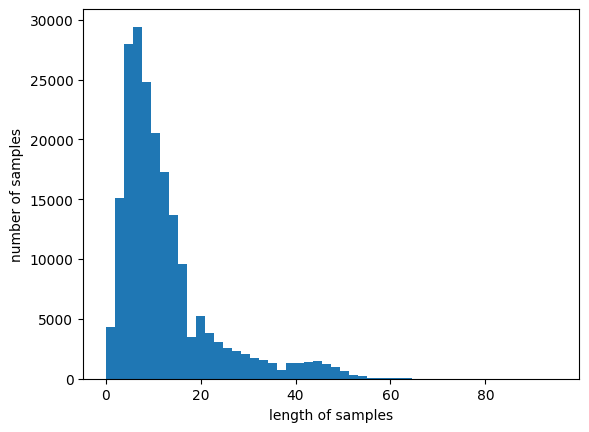

In [ ]:
# 리뷰 길이 분포 확인
print('리뷰의 최대 길이 :',max(len(l) for l in tokenized_data))
print('리뷰의 평균 길이 :',sum(map(len, tokenized_data))/len(tokenized_data))
plt.hist([len(s) for s in tokenized_data], bins=50)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

In [ ]:
from gensim.models import Word2Vec

In [ ]:
model = Word2Vec(sentences = tokenized_data, vector_size = 100, window = 5, min_count = 5, workers = 4, sg = 0)

In [ ]:
print('완성된 임베딩 매트릭스의 크기 확인 :', model.wv.vectors.shape)

완성된 임베딩 매트릭스의 크기 확인 : (17615, 100)


In [ ]:
print(model.wv.most_similar("최민식"))

[('한석규', 0.8571268320083618), ('설경구', 0.8452921509742737), ('최민수', 0.8338266611099243), ('김명민', 0.8124658465385437), ('박중훈', 0.812039852142334), ('이민호', 0.8060001730918884), ('이정재', 0.8057197332382202), ('오광록', 0.8046124577522278), ('신현준', 0.8035202622413635), ('주진모', 0.8033415079116821)]


In [ ]:
print(model.wv.most_similar("히어로"))

[('무협', 0.8497934937477112), ('슬래셔', 0.8465434312820435), ('호러', 0.8235810995101929), ('무비', 0.8234977722167969), ('물', 0.8231514096260071), ('sf', 0.8213315010070801), ('SF', 0.8211606740951538), ('정통', 0.8092053532600403), ('블록버스터', 0.8021263480186462), ('물의', 0.7981185913085938)]


In [ ]:
print(model.wv.most_similar("발연기"))

[('연기', 0.7589494585990906), ('어색', 0.7401741743087769), ('발음', 0.7336492538452148), ('연기력', 0.7193053960800171), ('조연', 0.7098639607429504), ('사투리', 0.6703755259513855), ('캐스팅', 0.6702212691307068), ('크리스찬', 0.6689532399177551), ('미스캐스팅', 0.6680278778076172), ('최민식', 0.6670196056365967)]


# 3. 사전 훈련된 Word2Vec

In [ ]:
!pip install gdown
!gdown https://drive.google.com/uc?id=1Av37IVBQAAntSe1X3MOAl5gvowQzd2_j

Downloading...
From (original): https://drive.google.com/uc?id=1Av37IVBQAAntSe1X3MOAl5gvowQzd2_j
From (redirected): https://drive.google.com/uc?id=1Av37IVBQAAntSe1X3MOAl5gvowQzd2_j&confirm=t&uuid=c9591fb5-34c2-49c7-97cb-c15373eadfba
To: /content/GoogleNews-vectors-negative300.bin.gz
100% 1.65G/1.65G [00:10<00:00, 157MB/s]


In [ ]:
import gensim

In [ ]:
word2vec_model = gensim.models.KeyedVectors.load_word2vec_format('GoogleNews-vectors-negative300.bin.gz', binary=True)

In [ ]:
print(word2vec_model.vectors.shape)

(3000000, 300)


In [ ]:
print(word2vec_model.similarity('this', 'is'))
print(word2vec_model.similarity('post', 'book'))

0.40797037
0.057204384


In [ ]:
print(word2vec_model['book'])

[ 0.11279297 -0.02612305 -0.04492188  0.06982422  0.140625    0.03039551
 -0.04370117  0.24511719  0.08740234 -0.05053711  0.23144531 -0.07470703
  0.21875     0.03466797 -0.14550781  0.05761719  0.00671387 -0.00701904
  0.13183594 -0.25390625  0.14355469 -0.140625   -0.03564453 -0.21289062
 -0.24804688  0.04980469 -0.09082031  0.14453125  0.05712891 -0.10400391
 -0.19628906 -0.20507812 -0.27539062  0.03063965  0.20117188  0.17382812
  0.09130859 -0.10107422  0.22851562 -0.04077148  0.02709961 -0.00106049
  0.02709961  0.34179688 -0.13183594 -0.078125    0.02197266 -0.18847656
 -0.17480469 -0.05566406 -0.20898438  0.04858398 -0.07617188 -0.15625
 -0.05419922  0.01672363 -0.02722168 -0.11132812 -0.03588867 -0.18359375
  0.28710938  0.01757812  0.02185059 -0.05664062 -0.01251221  0.01708984
 -0.21777344 -0.06787109  0.04711914 -0.00668335  0.08544922 -0.02209473
  0.31835938  0.01794434 -0.02246094 -0.03051758 -0.09570312  0.24414062
  0.20507812  0.05419922  0.29101562  0.03637695  0.04

## 4. 워드 임베딩 모델로부터 2개의 tsv 파일 생성하기

In [ ]:
!python -m gensim.scripts.word2vec2tensor --input eng_w2v --output eng_w2v

2024-09-05 14:00:40,331 - word2vec2tensor - INFO - running /usr/local/lib/python3.10/dist-packages/gensim/scripts/word2vec2tensor.py --input eng_w2v --output eng_w2v
2024-09-05 14:00:40,331 - keyedvectors - INFO - loading projection weights from eng_w2v
2024-09-05 14:00:41,700 - utils - INFO - KeyedVectors lifecycle event {'msg': 'loaded (21613, 100) matrix of type float32 from eng_w2v', 'binary': False, 'encoding': 'utf8', 'datetime': '2024-09-05T14:00:41.698943', 'gensim': '4.3.3', 'python': '3.10.12 (main, Mar 22 2024, 16:50:05) [GCC 11.4.0]', 'platform': 'Linux-6.1.85+-x86_64-with-glibc2.35', 'event': 'load_word2vec_format'}
2024-09-05 14:00:43,191 - word2vec2tensor - INFO - 2D tensor file saved to eng_w2v_tensor.tsv
2024-09-05 14:00:43,191 - word2vec2tensor - INFO - Tensor metadata file saved to eng_w2v_metadata.tsv
2024-09-05 14:00:43,193 - word2vec2tensor - INFO - finished running word2vec2tensor.py


In [ ]:
%ls -al

total 1750352
drwxr-xr-x 1 root root       4096 Sep  5 14:00 ./
drwxr-xr-x 1 root root       4096 Sep  5 12:55 ../
drwxr-xr-x 4 root root       4096 Jul 23 13:21 .config/
-rw-r--r-- 1 root root   25618916 Sep  5 12:59 eng_w2v
-rw-r--r-- 1 root root     179999 Sep  5 14:00 eng_w2v_metadata.tsv
-rw-r--r-- 1 root root   25438907 Sep  5 14:00 eng_w2v_tensor.tsv
-rw-r--r-- 1 root root 1647046227 Sep  5 13:20 GoogleNews-vectors-negative300.bin.gz
-rw-r--r-- 1 root root   19515078 Sep  5 12:59 ratings.txt
drwxr-xr-x 1 root root       4096 Jul 23 13:21 sample_data/
-rw-r--r-- 1 root root   74533638 Sep  5 12:57 ted_en-20160408.xml


In [ ]:
import gensim
gensim.__version__

'4.3.3'

In [ ]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
import urllib.request
import zipfile
from lxml import etree
import re
from nltk.tokenize import word_tokenize, sent_tokenize

In [ ]:
# 데이터 다운로드
urllib.request.urlretrieve("https://raw.githubusercontent.com/ukairia777/tensorflow-nlp-tutorial/main/09.%20Word%20Embedding/dataset/ted_en-20160408.xml", filename="ted_en-20160408.xml")

('ted_en-20160408.xml', <http.client.HTTPMessage at 0x7a040cf8b9a0>)

In [ ]:
targetXML = open('ted_en-20160408.xml', 'r', encoding='UTF8')
target_text = etree.parse(targetXML)

# xml 파일로부터 <content>와 </content> 사이의 내용만 가져온다.
parse_text = '\n'.join(target_text.xpath('//content/text()'))

# 정규 표현식의 sub 모듈을 통해 content 중간에 등장하는 (Audio), (Laughter) 등의 배경음 부분을 제거.
# 해당 코드는 괄호로 구성된 내용을 제거.
content_text = re.sub(r'\([^)]*\)', '', parse_text)

# 입력 코퍼스에 대해서 NLTK를 이용하여 문장 토큰화를 수행.
sent_text = sent_tokenize(content_text)

# 각 문장에 대해서 구두점을 제거하고, 대문자를 소문자로 변환.
normalized_text = []
for string in sent_text:
     tokens = re.sub(r"[^a-z0-9]+", " ", string.lower())
     normalized_text.append(tokens)

# 각 문장에 대해서 NLTK를 이용하여 단어 토큰화를 수행.
result = [word_tokenize(sentence) for sentence in normalized_text]

In [ ]:
print('총 샘플의 개수 : {}'.format(len(result)))

총 샘플의 개수 : 273424


In [ ]:
# 샘플 3개만 출력
for line in result[:3]:
    print(line)

['here', 'are', 'two', 'reasons', 'companies', 'fail', 'they', 'only', 'do', 'more', 'of', 'the', 'same', 'or', 'they', 'only', 'do', 'what', 's', 'new']
['to', 'me', 'the', 'real', 'real', 'solution', 'to', 'quality', 'growth', 'is', 'figuring', 'out', 'the', 'balance', 'between', 'two', 'activities', 'exploration', 'and', 'exploitation']
['both', 'are', 'necessary', 'but', 'it', 'can', 'be', 'too', 'much', 'of', 'a', 'good', 'thing']


In [ ]:
from gensim.models import Word2Vec
from gensim.models import KeyedVectors

In [ ]:
model = Word2Vec(sentences=result, vector_size=100, window=5, min_count=5, workers=4, sg=0)

여기서 Word2Vec의 인자는 다음과 같습니다.  

* size = 워드 벡터의 특징 값. 즉, 임베딩 된 벡터의 차원.
* window = 컨텍스트 윈도우 크기
* min_count = 단어 최소 빈도 수 제한 (빈도가 적은 단어들은 학습하지 않는다.)
* workers = 학습을 위한 프로세스 수
* sg = 0은 CBOW, 1은 Skip-gram.

In [ ]:
model_result = model.wv.most_similar("man")
print(model_result)

[('woman', 0.8298438787460327), ('guy', 0.8160174489021301), ('boy', 0.7708301544189453), ('lady', 0.7643314599990845), ('soldier', 0.7354176640510559), ('girl', 0.717927098274231), ('gentleman', 0.7089431285858154), ('kid', 0.6925562024116516), ('poet', 0.6804522275924683), ('rabbi', 0.660800576210022)]


In [ ]:
model.wv.save_word2vec_format('eng_w2v') # 모델 저장
loaded_model = KeyedVectors.load_word2vec_format("eng_w2v") # 모델 로드

In [ ]:
model_result = loaded_model.most_similar("man")
print(model_result)

[('woman', 0.8298438787460327), ('guy', 0.8160174489021301), ('boy', 0.7708301544189453), ('lady', 0.7643314599990845), ('soldier', 0.7354176640510559), ('girl', 0.717927098274231), ('gentleman', 0.7089431285858154), ('kid', 0.6925562024116516), ('poet', 0.6804522275924683), ('rabbi', 0.660800576210022)]


## 1. 패스트텍스트(FastText)

In [ ]:
model.wv.most_similar("electrofishing")

KeyError: "Key 'electrofishing' not present in vocabulary"

In [ ]:
from gensim.models import FastText

model = FastText(result, vector_size=100, window=5, min_count=5, workers=4, sg=1)

In [ ]:
model.wv.most_similar("electrofishing")

[('electrolux', 0.8638656735420227),
 ('electrolyte', 0.863554835319519),
 ('electroshock', 0.851119875907898),
 ('electro', 0.845746636390686),
 ('airbus', 0.8434563875198364),
 ('electronic', 0.8328495621681213),
 ('electrochemical', 0.8314330577850342),
 ('electroencephalogram', 0.8227949738502502),
 ('electric', 0.8153161406517029),
 ('electron', 0.8122215270996094)]

## 1. 임베딩 층은 룩업 테이블이다.

In [ ]:
import torch
import torch.nn as nn

In [ ]:
train_data = 'you need to know how to code'

# 중복을 제거한 단어들의 집합인 단어 집합 생성.
word_set = set(train_data.split())

# 단어 집합의 각 단어에 고유한 정수 맵핑.
vocab = {word: i+2 for i, word in enumerate(word_set)}
vocab['<unk>'] = 0
vocab['<pad>'] = 1
print(vocab)

{'to': 2, 'know': 3, 'how': 4, 'need': 5, 'code': 6, 'you': 7, '<unk>': 0, '<pad>': 1}


In [ ]:
# 단어 집합의 크기만큼의 행을 가지는 테이블 생성.
embedding_table = torch.FloatTensor([
                               [ 0.0,  0.0,  0.0],
                               [ 0.0,  0.0,  0.0],
                               [ 0.2,  0.9,  0.3],
                               [ 0.1,  0.5,  0.7],
                               [ 0.2,  0.1,  0.8],
                               [ 0.4,  0.1,  0.1],
                               [ 0.1,  0.8,  0.9],
                               [ 0.6,  0.1,  0.1]])

In [ ]:
sample = 'you need to run'.split()
idxes = []

# 각 단어를 정수로 변환
for word in sample:
  try:
    idxes.append(vocab[word])
  # 단어 집합에 없는 단어일 경우 <unk>로 대체된다.
  except KeyError:
    idxes.append(vocab['<unk>'])
idxes = torch.LongTensor(idxes)

# 각 정수를 인덱스로 임베딩 테이블에서 값을 가져온다.
lookup_result = embedding_table[idxes, :]
print(lookup_result)

tensor([[0.6000, 0.1000, 0.1000],
        [0.4000, 0.1000, 0.1000],
        [0.2000, 0.9000, 0.3000],
        [0.0000, 0.0000, 0.0000]])


## 2. 임베딩 층 사용하기

In [ ]:
train_data = 'you need to know how to code'

# 중복을 제거한 단어들의 집합인 단어 집합 생성.
word_set = set(train_data.split())

# 단어 집합의 각 단어에 고유한 정수 맵핑.
vocab = {tkn: i+2 for i, tkn in enumerate(word_set)}
vocab['<unk>'] = 0
vocab['<pad>'] = 1

In [ ]:
embedding_layer = nn.Embedding(num_embeddings=len(vocab),
                               embedding_dim=3,
                               padding_idx=1)

In [ ]:
print(embedding_layer.weight)

Parameter containing:
tensor([[ 1.1554, -0.6474,  0.0574],
        [ 0.0000,  0.0000,  0.0000],
        [ 1.0383, -1.8434, -0.5678],
        [ 0.4212, -0.5064,  2.0984],
        [ 0.4647,  0.0217,  1.3079],
        [-0.3444,  1.3380, -0.1798],
        [ 1.4049,  0.5206, -1.3689],
        [-0.6686,  1.2110,  0.9282]], requires_grad=True)


## 1. 사전 훈련된 임베딩을 사용하지 않는 경우

In [ ]:
import numpy as np
from collections import Counter
import gensim

In [ ]:
sentences = ['nice great best amazing', 'stop lies', 'pitiful nerd', 'excellent work', 'supreme quality', 'bad', 'highly respectable']
y_train = [1, 0, 0, 1, 1, 0, 1]

In [ ]:
tokenized_sentences = [sent.split() for sent in sentences]
print('단어 토큰화 된 결과 :', tokenized_sentences)

단어 토큰화 된 결과 : [['nice', 'great', 'best', 'amazing'], ['stop', 'lies'], ['pitiful', 'nerd'], ['excellent', 'work'], ['supreme', 'quality'], ['bad'], ['highly', 'respectable']]


In [ ]:
word_list = []
for sent in tokenized_sentences:
    for word in sent:
      word_list.append(word)

word_counts = Counter(word_list)
print('총 단어수 :', len(word_counts))

총 단어수 : 15


In [ ]:
# 등장 빈도순으로 정렬
vocab = sorted(word_counts, key=word_counts.get, reverse=True)
print(vocab)

['nice', 'great', 'best', 'amazing', 'stop', 'lies', 'pitiful', 'nerd', 'excellent', 'work', 'supreme', 'quality', 'bad', 'highly', 'respectable']


In [ ]:
word_to_index = {}
word_to_index['<PAD>'] = 0
word_to_index['<UNK>'] = 1

for index, word in enumerate(vocab) :
  word_to_index[word] = index + 2

vocab_size = len(word_to_index)
print('패딩 토큰, UNK 토큰을 고려한 단어 집합의 크기 :', vocab_size)

패딩 토큰, UNK 토큰을 고려한 단어 집합의 크기 : 17


In [ ]:
print(word_to_index)

{'<PAD>': 0, '<UNK>': 1, 'nice': 2, 'great': 3, 'best': 4, 'amazing': 5, 'stop': 6, 'lies': 7, 'pitiful': 8, 'nerd': 9, 'excellent': 10, 'work': 11, 'supreme': 12, 'quality': 13, 'bad': 14, 'highly': 15, 'respectable': 16}


In [ ]:
def texts_to_sequences(tokenized_X_data, word_to_index):
  encoded_X_data = []
  for sent in tokenized_X_data:
    index_sequences = []
    for word in sent:
      try:
          index_sequences.append(word_to_index[word])
      except KeyError:
          index_sequences.append(word_to_index['<UNK>'])
    encoded_X_data.append(index_sequences)
  return encoded_X_data

X_encoded = texts_to_sequences(tokenized_sentences, word_to_index)
print(X_encoded)

[[2, 3, 4, 5], [6, 7], [8, 9], [10, 11], [12, 13], [14], [15, 16]]


In [ ]:
max_len = max(len(l) for l in X_encoded)
print('최대 길이 :',max_len)

최대 길이 : 4


In [ ]:
def pad_sequences(sentences, max_len):
  features = np.zeros((len(sentences), max_len), dtype=int)
  for index, sentence in enumerate(sentences):
    if len(sentence) != 0:
      features[index, :len(sentence)] = np.array(sentence)[:max_len]
  return features

X_train = pad_sequences(X_encoded, max_len=max_len)
y_train = np.array(y_train)
print('패딩 결과 :')
print(X_train)

패딩 결과 :
[[ 2  3  4  5]
 [ 6  7  0  0]
 [ 8  9  0  0]
 [10 11  0  0]
 [12 13  0  0]
 [14  0  0  0]
 [15 16  0  0]]


In [ ]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader, TensorDataset

In [ ]:
class SimpleModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super(SimpleModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(embedding_dim * max_len, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # embedded.shape == (배치 크기, 문장의 길이, 임베딩 벡터의 차원)
        embedded = self.embedding(x)

        # flattend.shape == (배치 크기, 문장의 길이 × 임베딩 벡터의 차원)
        flattened = self.flatten(embedded)

        # output.shape == (배치 크기, 1)
        output = self.fc(flattened)
        return self.sigmoid(output)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

embedding_dim = 100
simple_model = SimpleModel(vocab_size, embedding_dim).to(device)

In [ ]:
criterion = nn.BCELoss()
optimizer = Adam(simple_model.parameters())

In [ ]:
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.long), torch.tensor(y_train, dtype=torch.float32))
train_dataloader = DataLoader(train_dataset, batch_size=2)

In [ ]:
print(len(train_dataloader))

4


In [ ]:
for epoch in range(10):
    for inputs, targets in train_dataloader:
        # inputs.shape == (배치 크기, 문장 길이)
        # targets.shape == (배치 크기)
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()

        # outputs.shape == (배치 크기)
        outputs = simple_model(inputs).view(-1)

        loss = criterion(outputs, targets)
        loss.backward()

        optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item()}")

Epoch 1, Loss: 0.875236988067627
Epoch 2, Loss: 0.6451760530471802
Epoch 3, Loss: 0.4630502164363861
Epoch 4, Loss: 0.34133291244506836
Epoch 5, Loss: 0.26545217633247375
Epoch 6, Loss: 0.2187986522912979
Epoch 7, Loss: 0.18912285566329956
Epoch 8, Loss: 0.16851575672626495
Epoch 9, Loss: 0.1521947830915451
Epoch 10, Loss: 0.1375783085823059


## 2. 사전 훈련된 임베딩을 사용하는 경우

In [ ]:
!pip install gdown
!gdown https://drive.google.com/uc?id=1Av37IVBQAAntSe1X3MOAl5gvowQzd2_j

Downloading...
From (original): https://drive.google.com/uc?id=1Av37IVBQAAntSe1X3MOAl5gvowQzd2_j
From (redirected): https://drive.google.com/uc?id=1Av37IVBQAAntSe1X3MOAl5gvowQzd2_j&confirm=t&uuid=470bb0f3-a860-4698-b942-a5d0be627a72
To: /content/GoogleNews-vectors-negative300.bin.gz
100% 1.65G/1.65G [00:15<00:00, 109MB/s]


In [ ]:
# 구글의 사전 훈련된 Word2vec 모델을 로드합니다.
word2vec_model = gensim.models.KeyedVectors.load_word2vec_format('GoogleNews-vectors-negative300.bin.gz', binary=True)

In [ ]:
embedding_matrix = np.zeros((vocab_size, 300))
print('임베딩 행렬의 크기 :', embedding_matrix.shape)

임베딩 행렬의 크기 : (17, 300)


In [ ]:
def get_vector(word):
    if word in word2vec_model:
        return word2vec_model[word]
    else:
        return None

In [ ]:
# <PAD>를 위한 0번과 <UNK>를 위한 1번은 실제 단어가 아니므로 맵핑에서 제외
for word, i in word_to_index.items():
    if i > 2:
      temp = get_vector(word)
      if temp is not None:
          embedding_matrix[i] = temp

In [ ]:
# <PAD>나 <UNK>의 경우는 사전 훈련된 임베딩이 들어가지 않아서 0벡터임
print(embedding_matrix[0])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [ ]:
word_to_index['great']

3

In [ ]:
# word2vec_model에서 'great'의 임베딩 벡터
# embedding_matrix[3]이 일치하는지 체크
np.all(word2vec_model['great'] == embedding_matrix[3])

True

In [ ]:
class PretrainedEmbeddingModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super(PretrainedEmbeddingModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding.weight = nn.Parameter(torch.tensor(embedding_matrix, dtype=torch.float32))
        self.embedding.weight.requires_grad = True
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(embedding_dim * max_len, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        embedded = self.embedding(x)
        flattened = self.flatten(embedded)
        output = self.fc(flattened)
        return self.sigmoid(output)

In [ ]:
pretraiend_embedding_model = PretrainedEmbeddingModel(vocab_size, 300).to(device)

In [ ]:
criterion = nn.BCELoss()
optimizer = Adam(pretraiend_embedding_model.parameters())

In [ ]:
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.long), torch.tensor(y_train, dtype=torch.float32))
train_dataloader = DataLoader(train_dataset, batch_size=2)

In [ ]:
print(len(train_dataloader))

4


In [ ]:
for epoch in range(10):
    for inputs, targets in train_dataloader:
        # inputs.shape == (배치 크기, 문장 길이)
        # targets.shape == (배치 크기)
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()

        # outputs.shape == (배치 크기)
        outputs = pretraiend_embedding_model(inputs).view(-1)

        loss = criterion(outputs, targets)
        loss.backward()

        optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item()}")

Epoch 1, Loss: 0.6507558822631836
Epoch 2, Loss: 0.5911518931388855
Epoch 3, Loss: 0.5319837927818298
Epoch 4, Loss: 0.476415753364563
Epoch 5, Loss: 0.42526787519454956
Epoch 6, Loss: 0.37870797514915466
Epoch 7, Loss: 0.3366509675979614
Epoch 8, Loss: 0.29889577627182007
Epoch 9, Loss: 0.2651826739311218
Epoch 10, Loss: 0.23521865904331207


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
sentence = "Repeat is the best medicine for memory".split()

In [ ]:
vocab = list(set(sentence))
print(vocab)

['memory', 'is', 'the', 'for', 'Repeat', 'best', 'medicine']


In [ ]:
word2index = {tkn: i for i, tkn in enumerate(vocab, 1)}  # 단어에 고유한 정수 부여
word2index['<unk>']=0

In [ ]:
print(word2index['memory'])

1


In [ ]:
# 수치화된 데이터를 단어로 바꾸기 위한 사전
index2word = {v: k for k, v in word2index.items()}
print(index2word)

{1: 'memory', 2: 'is', 3: 'the', 4: 'for', 5: 'Repeat', 6: 'best', 7: 'medicine', 0: '<unk>'}


In [ ]:
print(index2word[2])

is


In [ ]:
def build_data(sentence, word2index):
    encoded = [word2index[token] for token in sentence] # 각 문자를 정수로 변환.
    input_seq, label_seq = encoded[:-1], encoded[1:] # 입력 시퀀스와 레이블 시퀀스를 분리
    input_seq = torch.LongTensor(input_seq).unsqueeze(0) # 배치 차원 추가
    label_seq = torch.LongTensor(label_seq).unsqueeze(0) # 배치 차원 추가
    return input_seq, label_seq

In [ ]:
X, Y = build_data(sentence, word2index)

In [ ]:
class Net(nn.Module):
    def __init__(self, vocab_size, input_size, hidden_size, batch_first=True):
        super(Net, self).__init__()
        self.embedding_layer = nn.Embedding(num_embeddings=vocab_size, # 워드 임베딩
                                            embedding_dim=input_size)
        self.rnn_layer = nn.RNN(input_size, hidden_size, # 입력 차원, 은닉 상태의 크기 정의
                                batch_first=batch_first)
        self.linear = nn.Linear(hidden_size, vocab_size) # 출력은 원-핫 벡터의 크기를 가져야함. 또는 단어 집합의 크기만큼 가져야함.

    def forward(self, x):
        # 1. 임베딩 층
        # 크기변화: (배치 크기, 시퀀스 길이) => (배치 크기, 시퀀스 길이, 임베딩 차원)
        output = self.embedding_layer(x)
        # 2. RNN 층
        # 크기변화: (배치 크기, 시퀀스 길이, 임베딩 차원)
        # => output (배치 크기, 시퀀스 길이, 은닉층 크기), hidden (1, 배치 크기, 은닉층 크기)
        output, hidden = self.rnn_layer(output)
        # 3. 최종 출력층
        # 크기변화: (배치 크기, 시퀀스 길이, 은닉층 크기) => (배치 크기, 시퀀스 길이, 단어장 크기)
        output = self.linear(output)
        # 4. view를 통해서 배치 차원 제거
        # 크기변화: (배치 크기, 시퀀스 길이, 단어장 크기) => (배치 크기*시퀀스 길이, 단어장 크기)
        return output.view(-1, output.size(2))

In [ ]:
# 하이퍼 파라미터
vocab_size = len(word2index)  # 단어장의 크기는 임베딩 층, 최종 출력층에 사용된다. <unk> 토큰을 크기에 포함한다.
input_size = 5  # 임베딩 된 차원의 크기 및 RNN 층 입력 차원의 크기
hidden_size = 20  # RNN의 은닉층 크기

In [ ]:
# 모델 생성
model = Net(vocab_size, input_size, hidden_size, batch_first=True)
# 손실함수 정의
loss_function = nn.CrossEntropyLoss() # 소프트맥스 함수 포함이며 실제값은 원-핫 인코딩 안 해도 됨.
# 옵티마이저 정의
optimizer = optim.Adam(params=model.parameters())

In [ ]:
# 임의로 예측해보기. 가중치는 전부 랜덤 초기화 된 상태이다.
output = model(X)
print(output)

tensor([[-0.3396, -0.0498,  0.5445,  0.0155,  0.2364,  0.4760, -0.2998, -0.0805],
        [-0.0769, -0.1373,  0.5565,  0.0573,  0.1828,  0.5001, -0.1645,  0.0317],
        [-0.2831,  0.1319,  0.1576, -0.0971, -0.0756,  0.4306,  0.0078, -0.1124],
        [-0.3625,  0.2251,  0.3956, -0.0877, -0.1193,  0.3274, -0.1035, -0.1773],
        [-0.4791, -0.0161,  0.4765, -0.1165, -0.0812,  0.6174, -0.3888, -0.2633],
        [-0.2883,  0.1755,  0.4422, -0.0913, -0.1342,  0.4562, -0.4074, -0.3320]],
       grad_fn=<ViewBackward0>)


In [ ]:
print(output.shape)

torch.Size([6, 8])


In [ ]:
# 수치화된 데이터를 단어로 전환하는 함수
decode = lambda y: [index2word.get(x) for x in y]

In [ ]:
# 훈련 시작
for step in range(201):
    # 경사 초기화
    optimizer.zero_grad()
    # 순방향 전파
    output = model(X)
    # 손실값 계산
    loss = loss_function(output, Y.view(-1))
    # 역방향 전파
    loss.backward()
    # 매개변수 업데이트
    optimizer.step()
    # 기록
    if step % 40 == 0:
        print("[{:02d}/201] {:.4f} ".format(step+1, loss))
        pred = output.softmax(-1).argmax(-1).tolist()
        print(" ".join(["Repeat"] + decode(pred)))
        print()

[01/201] 2.0619 
Repeat is is Repeat is Repeat Repeat

[41/201] 1.4778 
Repeat is the best is for memory

[81/201] 0.7828 
Repeat is the best medicine for memory

[121/201] 0.3735 
Repeat is the best medicine for memory

[161/201] 0.1978 
Repeat is the best medicine for memory

[201/201] 0.1201 
Repeat is the best medicine for memory

